In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
from sklearn.preprocessing import StandardScaler, LabelEncoder

In [42]:
df_existing = pd.read_csv('df_existing.csv')

<h1 style="color: #e28de9; font-weight: bold;">CLUSTER ANALYSIS</h1>


In [43]:
from matplotlib.ticker import PercentFormatter
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


def _format_bars(ax, remove_legend=True):
    """Format bars and labels."""
    ax.yaxis.set_major_formatter(PercentFormatter(1))
    ax.set_ylabel("")
    ax.tick_params(axis="both", which="both", length=0)
    
    for bars in ax.containers:
        ax.bar_label(bars, label_type="center", 
                     labels=[f"{b.get_height():.1%}" for b in bars],
                     color="white", weight="bold", fontsize=11)
    
    for bar in ax.patches:
        bar.set_linewidth(0)
    
    legend = ax.get_legend()
    if remove_legend and legend:
        legend.remove()
    return legend


def plot_columns_percent_by_cluster(
    dataframe, columns, rows_cols=(2, 3), figsize=(15, 8),
    column_cluster="Cluster", palette='tab10', order=None
):
    fig, axs = plt.subplots(rows_cols[0], rows_cols[1], figsize=figsize, sharey=True)
    axs = np.atleast_1d(axs).flatten()
    
    for ax, col in zip(axs, columns):
        sns.histplot(x=column_cluster, hue=col, data=dataframe, ax=ax,
                    multiple="fill", stat="percent", discrete=True,
                    shrink=0.8, palette=palette, hue_order=order)
        ax.set_xticks(range(dataframe[column_cluster].nunique()))
        legend = _format_bars(ax)
    
    fig.legend(handles=legend.legend_handles, 
               labels=[t.get_text() for t in legend.get_texts()],
               loc="upper left", bbox_to_anchor=(0.9, 0.9), 
               ncols=1, title=col)
    plt.subplots_adjust(hspace=0.3, wspace=0.3)
    plt.show()


def plot_columns_percent_hue_cluster(
    dataframe, columns, rows_cols=(2, 3), figsize=(15, 8),
    column_cluster="Cluster", palette="tab10"
):
    fig, axs = plt.subplots(rows_cols[0], rows_cols[1], figsize=figsize, sharey=True)
    axs = np.atleast_1d(axs).flatten()
    
    for ax, col in zip(axs, columns):
        sns.histplot(x=col, hue=column_cluster, data=dataframe, ax=ax,
                    multiple="fill", stat="percent", discrete=True,
                    shrink=0.8, palette=palette)
        if dataframe[col].dtype != "object":
            ax.set_xticks(range(dataframe[col].nunique()))
        legend = _format_bars(ax)
    
    fig.legend(handles=legend.legend_handles,
               labels=[t.get_text() for t in legend.get_texts()],
               loc="upper center", ncols=dataframe[column_cluster].nunique(),
               title="Clusters")
    plt.subplots_adjust(hspace=0.3, wspace=0.3)
    plt.show()


def pairplot(dataframe, columns, hue_column=None, alpha=0.5, corner=True, palette="tab10"):
    analysis = columns.copy() + [hue_column]
    sns.pairplot(dataframe[analysis], diag_kind="kde", hue=hue_column,
                 plot_kws=dict(alpha=alpha), corner=corner, palette=palette)

In [61]:
def plot_boxplots_by_cluster(
    df, columns, ncols, figsize=(18, 5),
    palette=None, legend_title="Cluster"
):
    fig, axs = plt.subplots(nrows=1, ncols=ncols, figsize=figsize)
    axs = np.atleast_1d(axs)

    legend_handles, legend_labels = None, None

    for idx, (ax, col) in enumerate(zip(axs, columns)):
        sns.boxplot(
            x="Cluster",
            y=col,
            data=df,
            ax=ax,
            hue="Cluster",
            showmeans=True,
            palette=palette
        )
        ax.set_xlabel("")
        ax.set_title(col, fontsize=10)

        if idx == 0 and ax.get_legend():
            legend_handles = ax.get_legend().legend_handles
            legend_labels = [t.get_text() for t in ax.get_legend().get_texts()]

        if ax.get_legend():
            ax.get_legend().remove()

    if legend_handles:
        fig.legend(
            handles=legend_handles,
            labels=legend_labels,
            loc="upper left",
            bbox_to_anchor=(1.0, 0.9),
            frameon=True,
            title=legend_title
        )

    plt.tight_layout()
    plt.subplots_adjust(right=0.95)
    plt.show()


## **Numerical Variables**

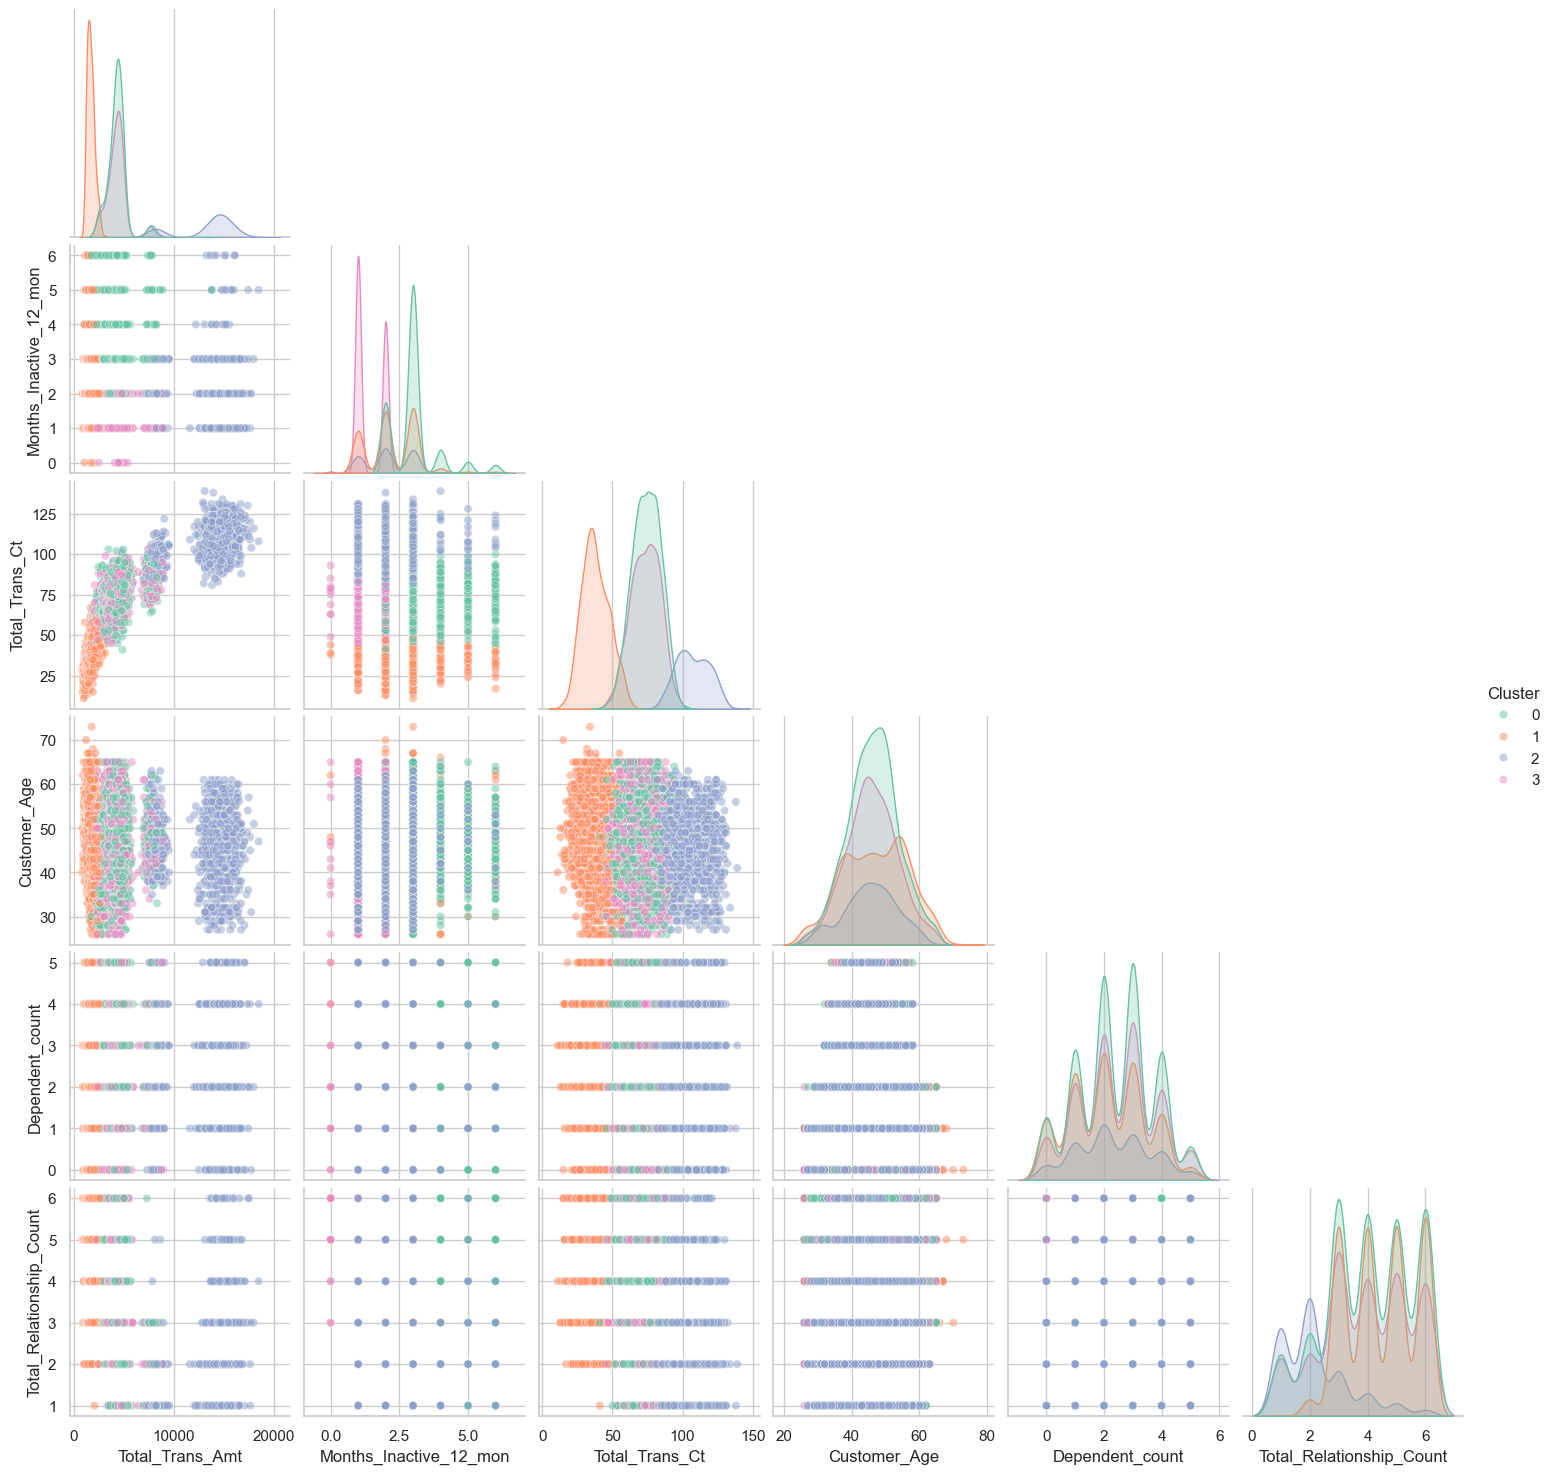

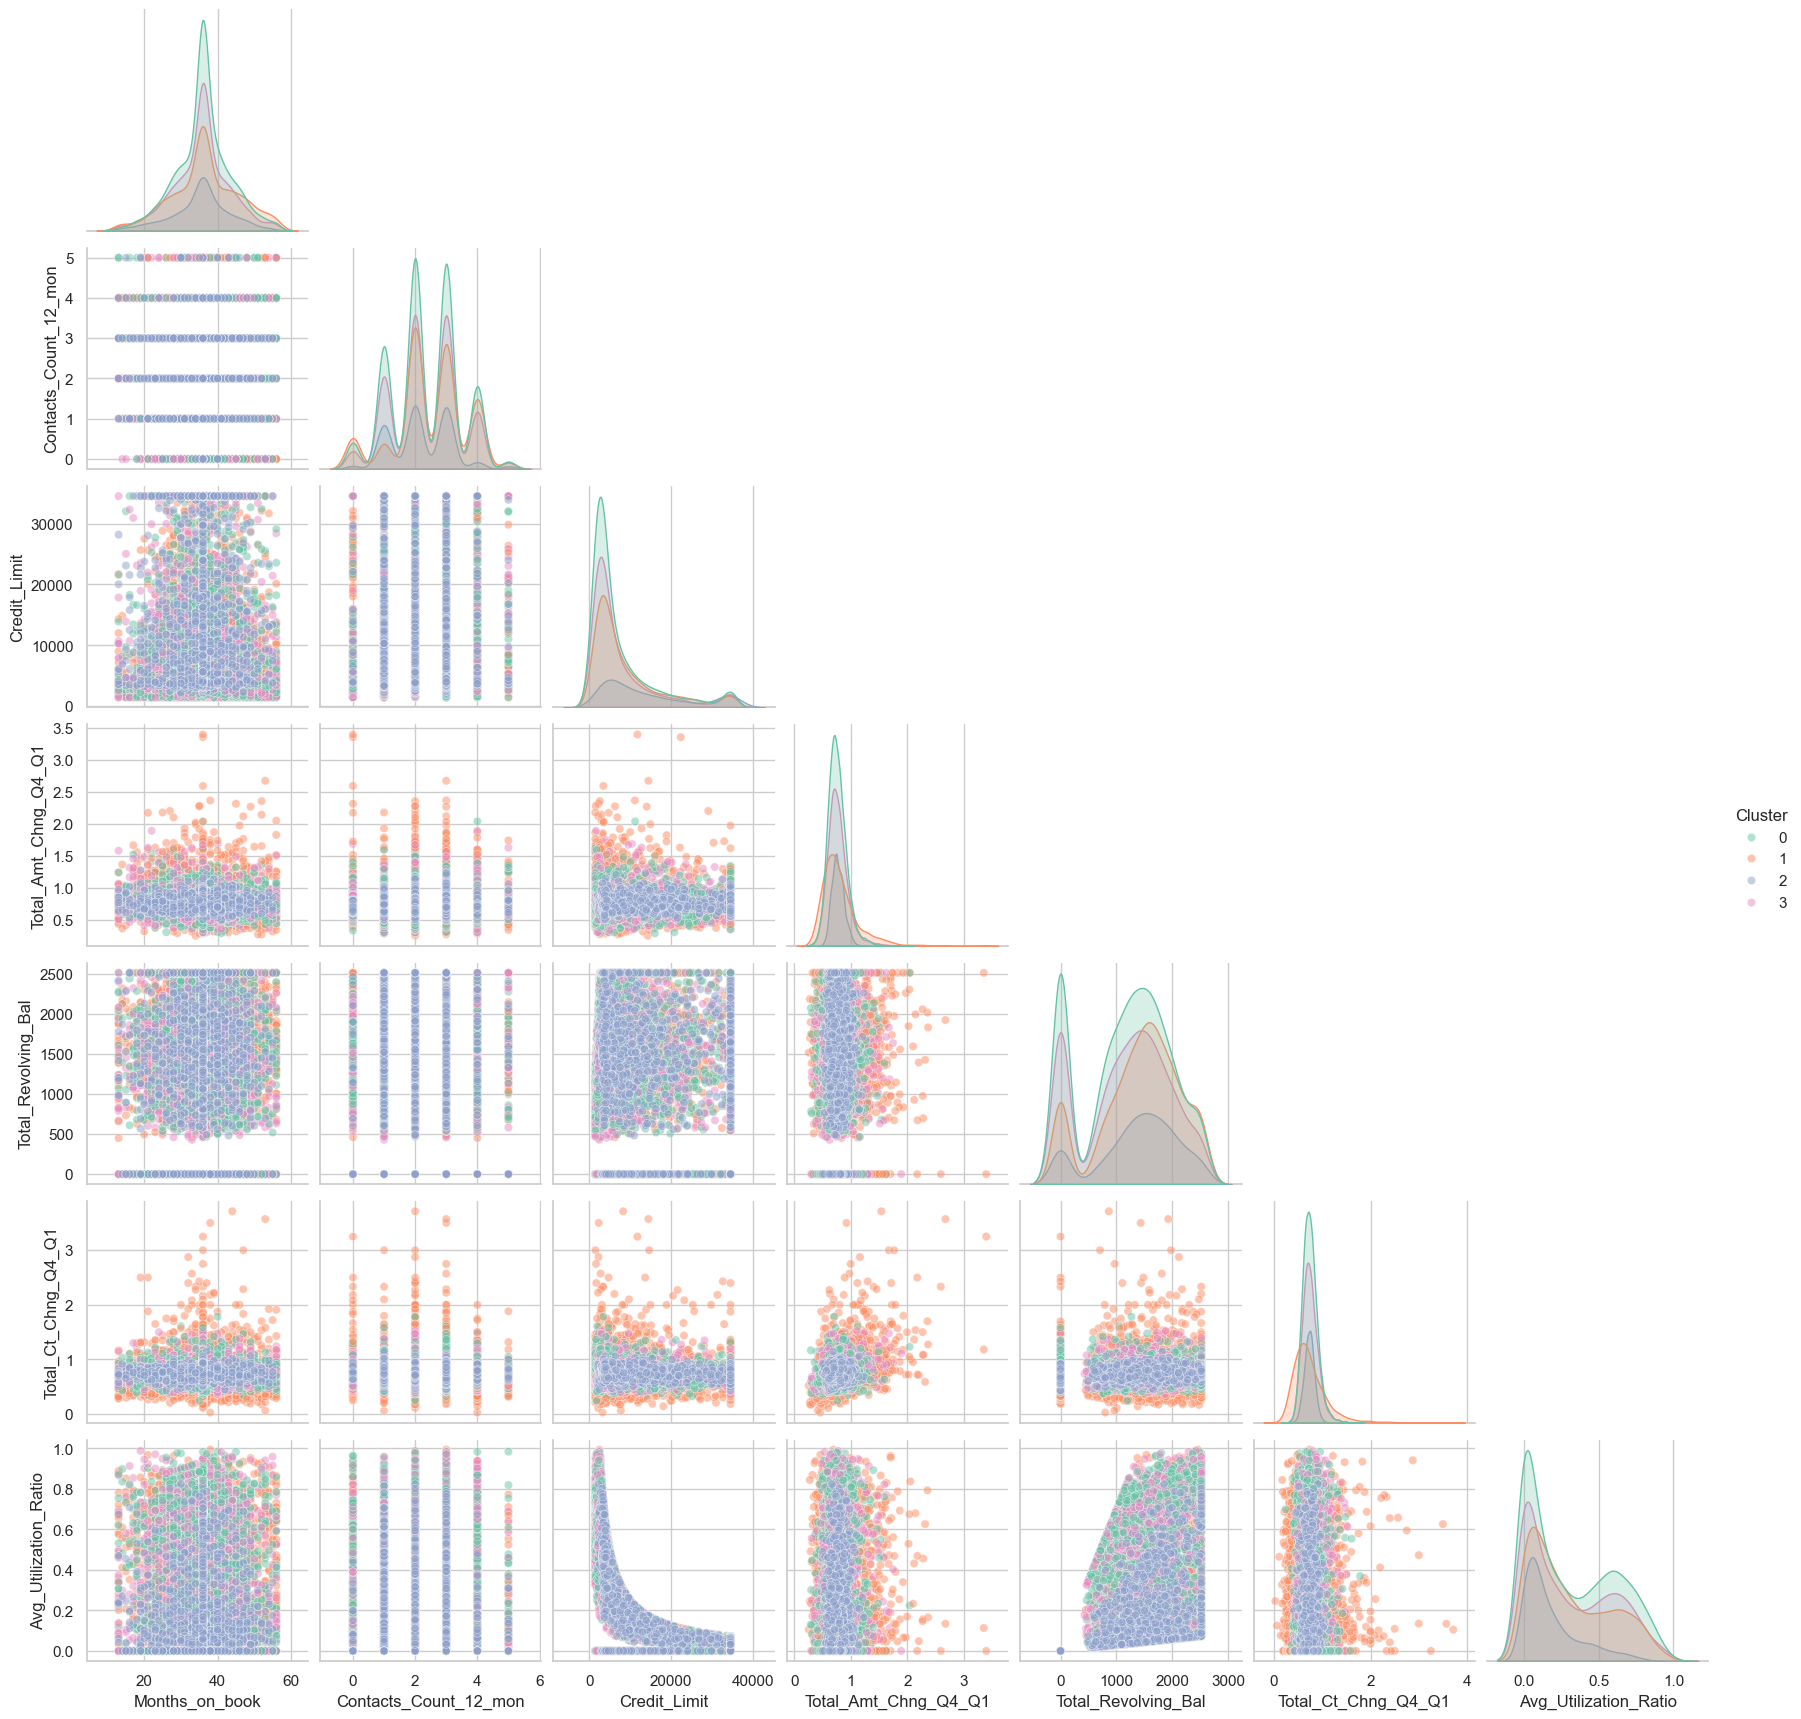

In [63]:
n_clusters = df_existing['Cluster'].nunique()
color_palette_cluster = sns.color_palette("Set2", n_clusters)

# Defining columns for analysis
columns_analysis = [
    "Total_Trans_Amt",
    "Months_Inactive_12_mon",
    "Total_Trans_Ct",
    "Customer_Age",
    "Dependent_count",
    "Total_Relationship_Count"
]
pairplot(df_existing, columns_analysis, hue_column="Cluster", palette=color_palette_cluster)

# Defining columns for analysis
columns_analysis_2 = [
    "Months_on_book",
    "Contacts_Count_12_mon",
    "Credit_Limit",
    "Total_Amt_Chng_Q4_Q1",
    "Total_Revolving_Bal",
    "Total_Ct_Chng_Q4_Q1",
    "Avg_Utilization_Ratio"
]
pairplot(df_existing, columns_analysis_2, hue_column="Cluster", palette=color_palette_cluster)


## <span style="color:pink; font-weight:700; text-transform:uppercase;"> STRONG DISCRIMINATING VARIABLES </span>

#### **Total_Trans_Amt (Total Transaction Amount)**
Total transaction amount is the strongest discriminating variable, with Cluster 2 completely separated from other clusters. This segment shows exceptionally high spending (≈10,000–20,000), far exceeding the rest. Cluster 1 records the lowest values (≈0–5,000), while Clusters 0 and 3 fall in the mid-range (≈5,000–10,000). The right-skewed distribution of Cluster 2 also indicates the presence of super-VIP customers generating extremely high transaction volumes.

#### **Total_Trans_Ct (Total Transaction Count)**
Transaction count further reinforces cluster separation. Cluster 2 exhibits the highest engagement (≈75–125 transactions), around 2–3 times higher than other clusters. Cluster 1 remains the least active (≈25–50 transactions). Overall, transaction count is positively correlated with transaction amount, but Cluster 2 consistently maintains higher spending even at similar frequencies, highlighting both high usage intensity and high transaction value.

#### **Months_Inactive_12_mon (Months of Inactivity)**
Inactivity clearly differentiates customer engagement levels. Cluster 2 is concentrated in the 0–2 month range, reflecting strong consistency and loyalty. In contrast, Cluster 1 shows wider dispersion (0–5 months), indicating unstable engagement and higher churn risk. Other clusters display more moderate and dispersed inactivity patterns.

#### **Customer_Age**
Customer age shows near-complete overlap across all clusters, centered around 40–60 years. This indicates that customer value and behavior are largely independent of age, suggesting that behavioral variables are more effective than demographics for segmentation.

#### **Dependent_Count & Total_Relationship_Count**
These variables show uniform distributions across clusters with no clear separation. Family structure and the number of banking relationships do not significantly explain differences in customer behavior and thus provide limited value for strategic segmentation.

## <span style="color:pink; font-weight:700; text-transform:uppercase;"> NON-DISCRIMINATING VARIABLES </span>

#### **Credit_Limit**

The credit limit distribution shows a clear separation between clusters. Cluster 2 is
distinctly positioned at the high end, with values mainly ranging from 15,000 to 40,000
and a strong concentration around 20,000. The remaining clusters largely overlap at
lower levels. Cluster 0 and Cluster 3 are concentrated between 5,000 and 15,000, while
Cluster 1 spans a wider range from 5,000 to 20,000 but without a pronounced peak.

#### **Avg_Utilization_Ratio**

Average credit utilization differs markedly across clusters. Cluster 2 is heavily
concentrated at very low utilization levels, primarily between 0.0 and 0.1. Cluster 0
shows much higher utilization, mostly between 0.4 and 0.8. Cluster 1 and Cluster 3 fall
in between, with utilization generally ranging from 0.2 to 0.6 and 0.2 to 0.5,
respectively.

#### **Total_Revolving_Bal**

Total revolving balance exhibits a bimodal pattern across clusters. Cluster 2 displays
two main concentration areas at low and mid-level balances. Cluster 1 is concentrated
toward the lower balance range, while Cluster 0 and Cluster 3 show similar distributions
centered around mid-level balances.

#### **Months_on_book**

Customer tenure shows almost complete overlap across all clusters. Distributions are
centered around 35–40 months, with nearly identical density curves, indicating no
meaningful differentiation by cluster.

#### **Contacts_Count_12_mon**

The number of contacts in the past 12 months is highly discrete and concentrated at
values of 2–3 for all clusters. Distributions are very similar across segments, with only
a small number of observations at higher contact levels (5–6).

#### **Total_Amt_Chng_Q4_Q1 and Total_Ct_Chng_Q4_Q1**

Both change-rate variables are mainly concentrated between 0.5 and 1.0 and show strong
overlap across clusters. The distributions form horizontal bands due to discretized
values, with a small number of higher-ratio observations, particularly visible in
Cluster 1.

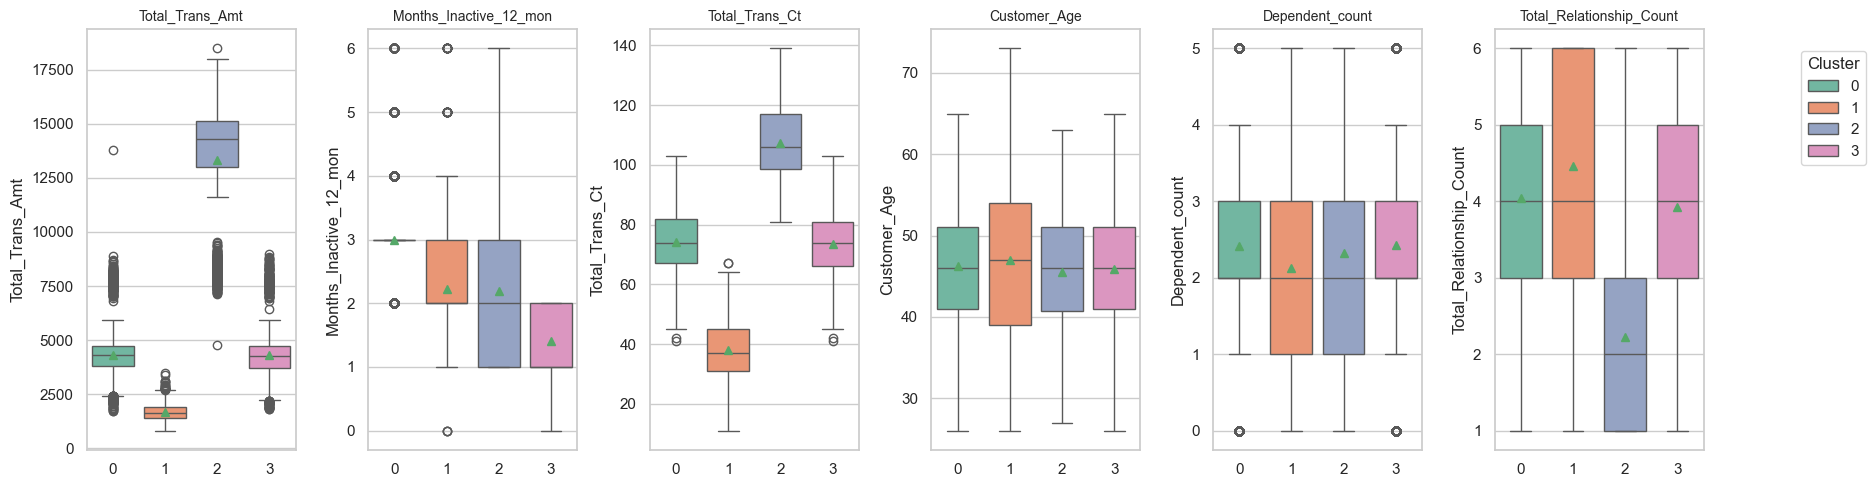

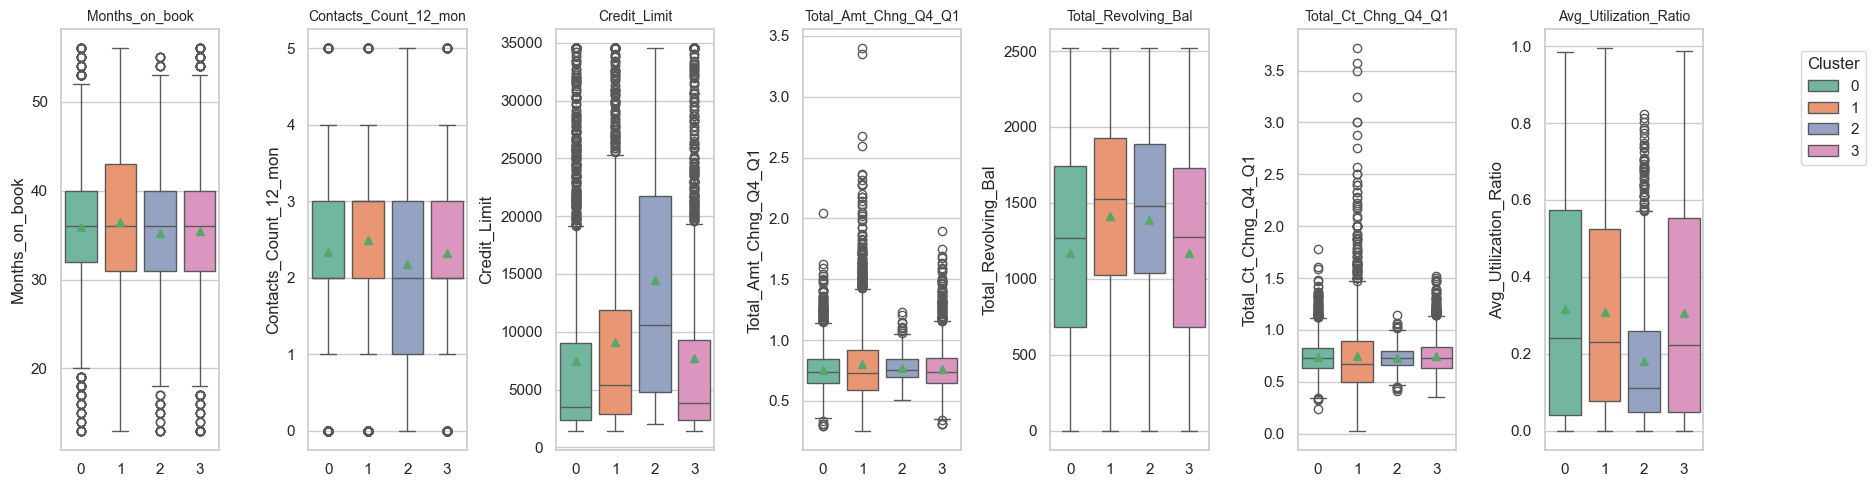

In [62]:
plot_boxplots_by_cluster(
    df=df_existing,
    columns=columns_analysis,
    ncols=6,
    figsize=(18, 5),
    palette=color_palette_cluster
)

plot_boxplots_by_cluster(
    df=df_existing,
    columns=columns_analysis_2,
    ncols=7,
    figsize=(18, 5),
    palette=color_palette_cluster
)




## <span style="color:pink; font-weight:700; text-transform:uppercase;"> STRONG DISCRIMINATING VARIABLES </span>

#### **Total_Trans_Amt (Total Transaction Amount)**
Total transaction amount is the strongest separator among clusters.  
Cluster 2 is completely isolated with substantially higher values, showing no overlap
with other clusters. Cluster 1 records the lowest transaction amounts, while Clusters 0
and 3 occupy a middle tier with similar distributions.

#### **Total_Trans_Ct (Total Transaction Count)**
Transaction count strongly reinforces the segmentation.  
Cluster 2 shows the highest and most consistent transaction frequency, while Cluster 1
has the lowest activity level. Clusters 0 and 3 display moderate and overlapping patterns.

#### **Months_Inactive_12_mon (Months of Inactivity)**
Inactivity patterns vary across clusters but are less cleanly separated than transaction
metrics. Cluster 2 generally exhibits low inactivity, indicating strong engagement,
whereas Cluster 1 shows more variability, suggesting unstable usage behavior.

#### **Total_Relationship_Count (Number of Products)**
Product holdings show an inverse pattern relative to customer value.  
Cluster 2, despite being the highest-value segment, holds the fewest products, while
Cluster 1 holds the most.

## <span style="color:pink; font-weight:700; text-transform:uppercase;"> NON-DISCRIMINATING VARIABLES </span>

#### **Customer_Age**
Customer age shows nearly identical distributions across all clusters, with overlapping
medians and interquartile ranges.

#### **Credit_Limit** 
This shows strong separation, with Cluster 2 having substantially higher limits
than all other clusters, which overlap at lower ranges. 

#### **Avg_Utilization_Ratio** 
It exhibits an inverse pattern, where Cluster 2 consistently has the lowest utilization, while Clusters 0 and 1 show higher and more dispersed usage levels.

#### **Total_Revolving_Bal** 
This follows a bimodal structure, with Cluster 2 and Cluster 0 centered at
higher balances, Cluster 1 concentrated at lower values, and Cluster 3 positioned in the
mid-range. I

#### **Months_on_book** and **Contacts_Count_12_mon** 
These display very similar
medians and interquartile ranges across all clusters, indicating limited discriminatory
power.

#### **Total_Amt_Chng_Q4_Q1** and **Total_Ct_Chng_Q4_Q1** 
These show substantial
overlap among clusters, with most values concentrated around stable growth levels and
only a few outliers differentiating segments.



## **Categorical Variables**

'Gender', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category', 'Last_Activity_Date', 'RFM_Level', 'Customer_Tag']

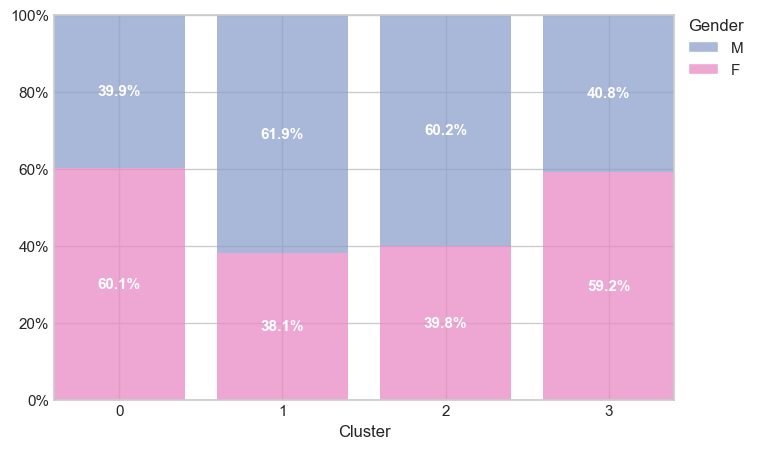

In [48]:
plot_columns_percent_by_cluster(
    dataframe=df_existing,
    columns=["Gender"],
    rows_cols=(1, 1),
    figsize=(8, 5),
    palette=['#8da0cb', '#e78ac3']

)

We can observe that the customers in Cluster 0 and Cluster 3 are predominantly female, representing around 60% of the total. In Cluster 1 and Cluster 2, male presence is predominant, covering around 60% of the customers.

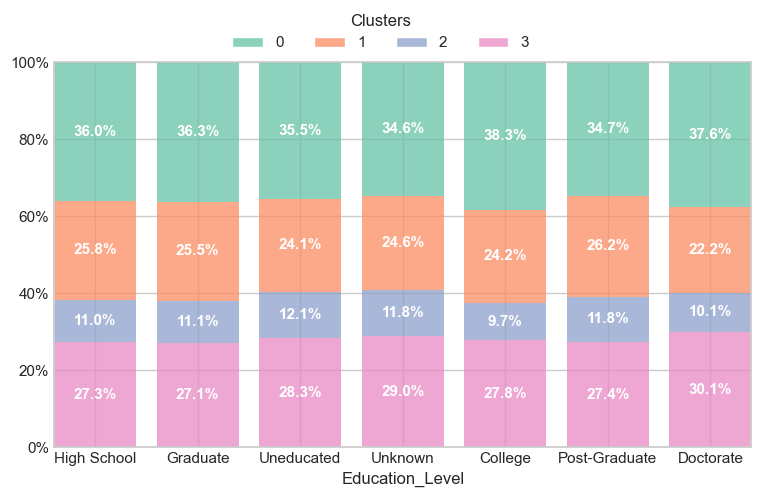

In [47]:
plot_columns_percent_hue_cluster(
    dataframe=df_existing,
    columns=["Education_Level"],
    rows_cols=(1, 1),
    figsize=(9, 5),
    palette=color_palette_cluster
)

The level of education remains virtually the same distribution across all clusters.

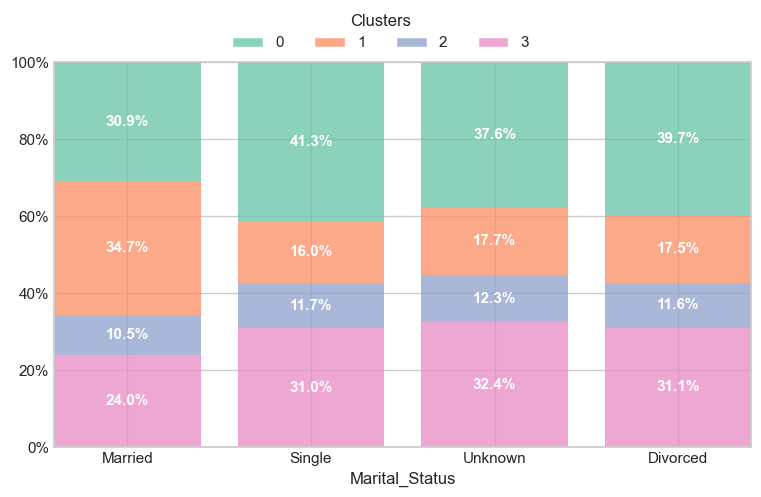

In [64]:
plot_columns_percent_hue_cluster(
    dataframe=df_existing,
    columns=["Marital_Status"],
    rows_cols=(1, 1),
    figsize=(9, 5),
    palette=color_palette_cluster
)

This stacked bar chart reveals that marital status provides minimal discriminatory power for customer segmentation, with most clusters showing similar proportions across all marital categories. Marital status is a weak predictor.


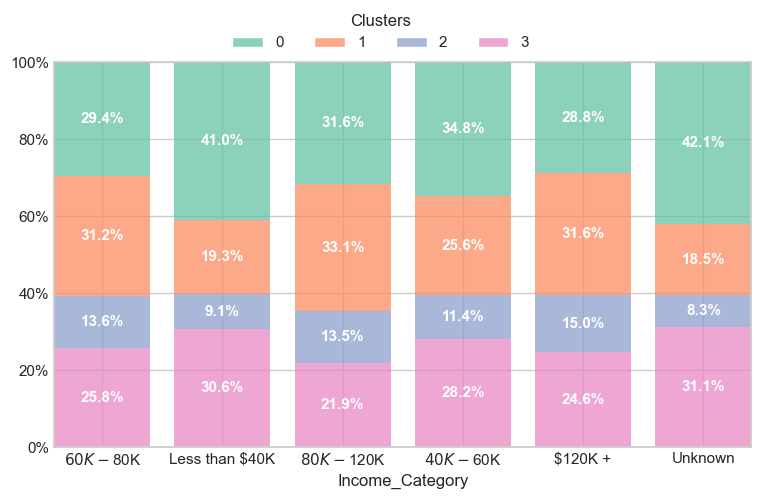

In [68]:
plot_columns_percent_hue_cluster(
    dataframe=df_existing,
    columns=["Income_Category"],
    rows_cols=(1, 1),
    figsize=(9, 5),
    palette=color_palette_cluster
)

Customers in Cluster 0 and Cluster 3 have the highest income. 40% of the customers are allocated in the top 2 income categories (80-120k and 120k).
In clusters 1 and 2, approximately half of the customers are allocated in the lowest income range, earning up to 40k annually.

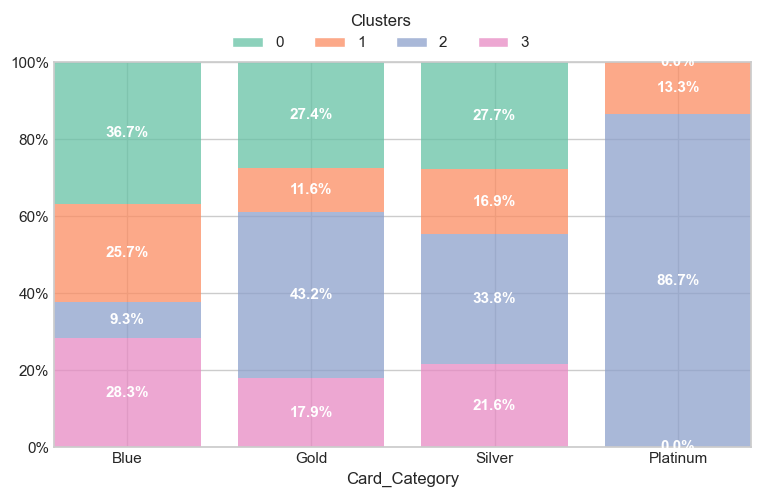

In [67]:
plot_columns_percent_hue_cluster(
    dataframe=df_existing,
    columns=["Card_Category"],
    rows_cols=(1, 1),
    figsize=(9, 5),
    palette=color_palette_cluster
)

This stacked bar chart shows a strong discriminatory pattern where card category clearly differentiates customer clusters. Platinum cardholders are overwhelmingly concentrated in Cluster 2 (86.7%), indicating this cluster represents premium customers with high-tier card products. Gold and Silver cards show Cluster 2 as the largest segment (43.2% and 33.8% respectively) but with more balanced distributions across other clusters. Blue cardholders display the most diverse cluster distribution, with Cluster 0 (36.7%) slightly leading, followed by Cluster 3 (28.3%) and Cluster 1 (25.7%), while Cluster 2 comprises only 9.3%, confirming that premium Cluster 2 customers predominantly hold higher-tier cards rather than basic Blue cards.


## **Cluster Profile**

#### **Cluster 0 – Moderate Spenders with High Credit Utilization**

Cluster 0 represents customers with moderate transaction amounts and transaction counts, typically positioned in the mid-range compared to other clusters. Their credit limits are relatively low to medium, yet they exhibit high average credit utilization, indicating intensive use of available credit. Revolving balances are generally at mid-levels, and inactivity is moderate, suggesting regular but not exceptional engagement. Customers in this cluster tend to hold a relatively high number of banking products, but their overall monetary contribution remains moderate.

#### **Cluster 1 – Low-Value and Unstable Customers**

Cluster 1 is characterized by the lowest transaction amounts and transaction counts among all clusters. Spending levels are minimal, and engagement is inconsistent, as reflected by high variability in months of inactivity. Although these customers often hold a relatively large number of banking products, their credit utilization and transaction behavior suggest low actual usage. Credit limits and revolving balances are generally low, positioning this cluster as the lowest-value segment with higher potential churn risk.

#### **Cluster 2 – High-Value, Highly Engaged Customers**

Cluster 2 is the most distinct and highest-value segment. Customers in this cluster show exceptionally high transaction amounts and transaction frequencies, with complete separation from other clusters in monetary value. They possess the highest credit limits while maintaining very low credit utilization ratios, indicating strong financial capacity and disciplined usage. Inactivity levels are generally low, reflecting consistent engagement. Despite their high value, these customers tend to hold fewer banking products, concentrating their activity in a limited number of high-impact services.

#### **Cluster 3 – Moderate Spenders with Stable Behavior**

Cluster 3 consists of customers with moderate transaction amounts and counts, similar to Cluster 0 but with slightly more stable engagement patterns. Credit limits are low to medium, utilization ratios fall in the mid-range, and revolving balances are comparable to Cluster 0. Inactivity levels are relatively low, suggesting consistent usage, although spending intensity remains moderate. Product holdings are average, and overall behavior reflects a stable but non-premium customer segment.